<h2 style="text-align: center;"> DEBER PREDICCIONES ENERGÉTICAS </h2>

<img src="img/ITQ.jpg" width="700">

**Fecha:** *10/6/2026* <br>
**Nombre:** *Sebastian Sampedro* <br>
**Link Github:** "https://github.com/sdsampedro-byte/Python2026ML"

### Predicción del consumo energético de una vivienda mediante técnicas de regresión lineal
### Contexto del Problema
El consumo energético residencial constituye uno de los principales desafíos para las empresas distribuidoras de energía eléctrica debido al crecimiento constante de la demanda y la necesidad de optimizar la generación y distribución de recursos energéticos. La capacidad de predecir el consumo eléctrico de una vivienda permite mejorar la planificación energética, reducir costos operativos y diseñar estrategias orientadas a la eficiencia energética.

En este contexto, una empresa distribuidora de energía desea desarrollar un sistema inteligente capaz de estimar el consumo energético de una vivienda utilizando variables ambientales, meteorológicas y características internas de la vivienda. Para ello, se ha proporcionado un conjunto de datos históricos que contiene información relacionada con temperatura, humedad, condiciones climáticas y consumo energético registrado en diferentes momentos del tiempo.

Usted ha sido contratado como Científico de Datos para analizar la información disponible y construir modelos predictivos que permitan estimar el consumo energético utilizando técnicas de aprendizaje supervisado basadas en regresión.
### Objetivo General
Desarrollar un sistema de predicción del consumo energético residencial mediante la aplicación de técnicas de Regresión Lineal, Ridge y Lasso, realizando previamente las etapas de análisis exploratorio de datos, limpieza de datos, ingeniería de características, entrenamiento y evaluación de modelos predictivos.
### Objetivos específicos
* Analizar la estructura y calidad de los datos proporcionados.
* Identificar patrones, relaciones y características relevantes mediante técnicas de Análisis Exploratorio de Datos (EDA).
* Aplicar procedimientos de limpieza y preparación de datos.
* Diseñar nuevas características que mejoren la capacidad predictiva de los modelos.
* Implementar modelos de Regresión Lineal, Ridge y Lasso.
* Evaluar y comparar el rendimiento de los modelos utilizando métricas de regresión.
* Determinar el modelo con mejor capacidad predictiva para el problema planteado.
### Dataset a utilizar
Utilizar el dataset:

Appliances Energy Prediction Dataset

<a href="https://archive.ics.uci.edu/dataset/374/appliances+energy+prediction">Descargar DataSet</a>

Variables principales:

* Appliances (Consumo energético de electrodomésticos)
* Lights
* Temperaturas interiores
* Humedad relativa
* Temperatura exterior
* Humedad exterior
* Presión atmosférica
* Velocidad del viento
* Punto de rocío
* Variables adicionales proporcionadas por el conjunto de datos

## Desarrollo de la Actividad
#### Fase 1. Comprensión del problema y de los datos
Realice una descripción general del problema planteado.

Analice el conjunto de datos y responda:

* ¿Cuántos registros posee el dataset?
* ¿Cuántas variables contiene?
* ¿Qué tipos de datos existen?
* ¿Cuál será la variable objetivo del modelo?
* ¿Qué variables podrían influir en el consumo energético?

Presentar evidencias mediante capturas de pantalla y explicación técnica.

In [1]:
# Instalación de la herramienta de UCI - Librería necesaria para conectarse con el repositorio.
!pip install ucimlrepo

In [2]:
# Manejo de datos y visualización
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Preprocesamiento y Modelos Lineales
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Métricas de evaluación
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
from ucimlrepo import fetch_ucirepo 
  
# Descargar el dataset usando su ID oficial
appliances_energy = fetch_ucirepo(id=374) 
  
# Extraer toda la tabla original y guardarla en la variable 'df'
df = appliances_energy.data.original 
  
# Mostrar las primeras 10 filas para confirmar la carga
df.head(10)

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-1117:00:00,60,30,19.890000,47.596667,19.20,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.60,733.500000,92.000000,7.000000,63.000000,5.30,13.275433,13.275433
1,2016-01-1117:10:00,60,30,19.890000,46.693333,19.20,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.48,733.600000,92.000000,6.666667,59.166667,5.20,18.606195,18.606195
2,2016-01-1117:20:00,50,30,19.890000,46.300000,19.20,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.37,733.700000,92.000000,6.333333,55.333333,5.10,28.642668,28.642668
3,2016-01-1117:30:00,50,40,19.890000,46.066667,19.20,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.25,733.800000,92.000000,6.000000,51.500000,5.00,45.410390,45.410390
4,2016-01-1117:40:00,60,40,19.890000,46.333333,19.20,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.13,733.900000,92.000000,5.666667,47.666667,4.90,10.084097,10.084097
5,2016-01-1117:50:00,50,40,19.890000,46.026667,19.20,44.500000,19.79,44.933333,18.890000,...,17.000000,45.29,6.02,734.000000,92.000000,5.333333,43.833333,4.80,44.919484,44.919484
6,2016-01-1118:00:00,60,50,19.890000,45.766667,19.20,44.500000,19.79,44.900000,18.890000,...,17.000000,45.29,5.90,734.100000,92.000000,5.000000,40.000000,4.70,47.233763,47.233763
7,2016-01-1118:10:00,60,50,19.856667,45.560000,19.20,44.500000,19.73,44.900000,18.890000,...,17.000000,45.29,5.92,734.166667,91.833333,5.166667,40.000000,4.68,33.039890,33.039890
8,2016-01-1118:20:00,60,40,19.790000,45.597500,19.20,44.433333,19.73,44.790000,18.890000,...,17.000000,45.29,5.93,734.233333,91.666667,5.333333,40.000000,4.67,31.455702,31.455702
9,2016-01-1118:30:00,70,40,19.856667,46.090000,19.23,44.400000,19.79,44.863333,18.890000,...,17.000000,45.29,5.95,734.300000,91.500000,5.500000,40.000000,4.65,3.089314,3.089314


In [4]:
# Mostramos los detalles de nuesto dataset
df.info()
# Verificamos si tenemos datos nulos si lo tenemos lo sumamos 
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19735 non-null  str    
 1   Appliances   19735 non-null  int64  
 2   lights       19735 non-null  int64  
 3   T1           19735 non-null  float64
 4   RH_1         19735 non-null  float64
 5   T2           19735 non-null  float64
 6   RH_2         19735 non-null  float64
 7   T3           19735 non-null  float64
 8   RH_3         19735 non-null  float64
 9   T4           19735 non-null  float64
 10  RH_4         19735 non-null  float64
 11  T5           19735 non-null  float64
 12  RH_5         19735 non-null  float64
 13  T6           19735 non-null  float64
 14  RH_6         19735 non-null  float64
 15  T7           19735 non-null  float64
 16  RH_7         19735 non-null  float64
 17  T8           19735 non-null  float64
 18  RH_8         19735 non-null  float64
 19  T9           19

date           0
Appliances     0
lights         0
T1             0
RH_1           0
T2             0
RH_2           0
T3             0
RH_3           0
T4             0
RH_4           0
T5             0
RH_5           0
T6             0
RH_6           0
T7             0
RH_7           0
T8             0
RH_8           0
T9             0
RH_9           0
T_out          0
Press_mm_hg    0
RH_out         0
Windspeed      0
Visibility     0
Tdewpoint      0
rv1            0
rv2            0
dtype: int64

In [5]:
# Borramos la columna Fecha ya que no es una variable importante o potencial para entrenar el modelo
df = df.drop(columns=['date'])

In [6]:
# Mostrar las primeras 5 filas para confirmar la eliminación de la Columna Fecha
df.head()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,...,17.033333,45.53,6.60,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,...,17.066667,45.56,6.48,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,...,17.000000,45.50,6.37,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,...,17.000000,45.40,6.25,733.8,92.0,6.000000,51.500000,5.0,45.410390,45.410390
4,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,...,17.000000,45.40,6.13,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [7]:
# Variable dependiente (objetivo)
y = df['Appliances']

# Variables independientes (todas las demás columnas que ayudarán a predecir)
X = df.drop(columns=['Appliances'])

### ANÁLISIS FASE 1
- ¿Cuántos registros posee el dataset? <br>
El dataset posee exactamente 19,735 registros (Contando la columna 'fecha' que posteriormente fue eliminada)<br>
- ¿Cuántas variables contiene? <br>
Contiene 29 variables (Contando la columna 'fecha' que posteriormente fue eliminada), quitando la columna eliminada quedan 28 variables, 1 variable dependiente (objetivo (y)) y 27 variables independientes (X) que son las mediciones de los sensores que ayudarán a la predicción (temperatura, humedad, clima exterior, etc.). <br>
- ¿Qué tipos de datos existen? <br>
**float64 (Números decimales):** Es el tipo de dato predominante (26 variables). Aquí se agrupan todas las mediciones continuas de los sensores, como las temperaturas (ej. 21.5 °C) y los porcentajes de humedad (ej. 45.2%). <br>
**int64 (Números enteros):** Solo dos columnas tienen este formato sin decimales. Estas son nuestra variable objetivo Appliances (consumo en Wh) y la variable lights (consumo de los focos). <br>
Ambos son datos cuantitativos, lo que significa que nuestra matriz está en el formato perfecto para que las ecuaciones matemáticas de los modelos de regresión puedan procesarlos. <br>
- ¿Cuál será la variable objetivo del modelo? <br>
La variable objetivo o dependiente de nuestro modelo será **Appliances**. Esta columna contiene el consumo de energía de los electrodomésticos (medido en Wh). Es exactamente el valor que queremos que nuestro modelo aprenda a predecir basándose en el resto de las condiciones de la matriz X (temperaturas, humedad, etc.). <br>
- ¿Qué variables podrían influir en el consumo energético? <br>
Las variables que influyen físicamente en el consumo de los electrodomésticos están ligadas al clima y al entorno. En este dataset específico, las variables son: <br>
**La temperatura:** Medida por los sensores en diferentes áreas de la vivienda (cocina, sala, cuarto principal, exterior, etc.). <br>
**La humedad:** Registrada también en las distintas zonas internas y externas. <br>
**Factores meteorológicos:** Como la velocidad del viento, la presión atmosférica y la visibilidad. <br>
Muchas de estas variables suben o bajan al mismo tiempo (ej. la temperatura de la sala y la cocina). Esto genera multicolinealidad (información redundante), lo que significa que para el modelo de regresión lineal, no todas las variables terminarán siendo igual de útiles o importantes.

## Fase 2. Análisis Exploratorio de Datos (EDA)

Realizar un análisis exploratorio completo del conjunto de datos.

El análisis deberá incluir:

#### 2.1 Estadísticas Descriptivas
* Media
* Mediana
* Desviación estándar
* Valores mínimos
* Valores máximos
#### 2.2 Identificación de Valores Faltantes

Determinar:

* Cantidad de valores faltantes por variable.
* Estrategia utilizada para su tratamiento.
#### 2.3 Distribución de Variables

* Generar histogramas para las principales variables numéricas.

* Interpretar los resultados obtenidos.

#### 2.4 Matriz de Correlación

Construir una matriz de correlación e identificar:

* Variables con correlación positiva fuerte.
* Variables con correlación negativa fuerte.
* Variables con correlación débil.
* Variable con mayor relación respecto al consumo energético.
#### 2.5 Visualizaciones Adicionales

Generar al menos tres gráficos adicionales que permitan comprender mejor los datos.

Ejemplos:

* Boxplots
* Scatterplots
* Pairplots
* Heatmaps

Cada gráfico deberá incluir su respectiva interpretación.

In [8]:
# 2.1 Resumen de estadística descriptiva para las variables numéricas
df.describe()

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
count,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,...,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000
mean,97.694958,3.801875,21.686571,40.259739,20.341219,40.420420,22.267611,39.242500,20.855335,39.026904,...,19.485828,41.552401,7.412580,755.522602,79.750418,4.039752,38.330834,3.760995,24.988033,24.988033
std,102.524891,7.935988,1.606066,3.979299,2.192974,4.069813,2.006111,3.254576,2.042884,4.341321,...,2.014712,4.151497,5.318464,7.399441,14.901088,2.451221,11.794719,4.195248,14.496634,14.496634
min,10.000000,0.000000,16.790000,27.023333,16.100000,20.463333,17.200000,28.766667,15.100000,27.660000,...,14.890000,29.166667,-5.000000,729.300000,24.000000,0.000000,1.000000,-6.600000,0.005322,0.005322
25%,50.000000,0.000000,20.760000,37.333333,18.790000,37.900000,20.790000,36.900000,19.530000,35.530000,...,18.000000,38.500000,3.670000,750.933333,70.333333,2.000000,29.000000,0.900000,12.497889,12.497889
50%,60.000000,0.000000,21.600000,39.656667,20.000000,40.500000,22.100000,38.530000,20.666667,38.400000,...,19.390000,40.900000,6.920000,756.100000,83.666667,3.666667,40.000000,3.430000,24.897653,24.897653
75%,100.000000,0.000000,22.600000,43.066667,21.500000,43.260000,23.290000,41.760000,22.100000,42.156667,...,20.600000,44.338095,10.400000,760.933333,91.666667,5.500000,40.000000,6.570000,37.583769,37.583769
max,1080.000000,70.000000,26.260000,63.360000,29.856667,56.026667,29.236000,50.163333,26.200000,51.090000,...,24.500000,53.326667,26.100000,772.300000,100.000000,14.000000,66.000000,15.500000,49.996530,49.996530


##### 2.2 Identificación de Valores Faltantes
Al verificar el dataset, se determinó que no existen valores faltantes (0 nulos) en ninguna de las variables. Por lo tanto, la estrategia adoptada es conservar los datos originales intactos, sin necesidad de aplicar técnicas de imputación (como cálculos de medianas) ni eliminación de registros.

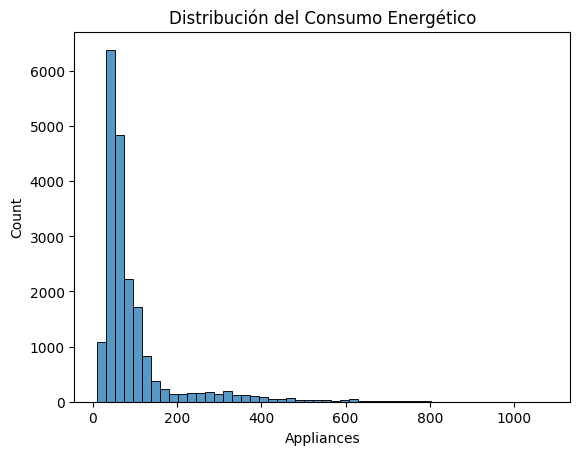

In [9]:
# Crea un histograma usando la tabla 'df' y la columna 'Appliances'
# 'bins=50' divide el rango de datos en 50 barras o grupos para ver el detalle
sns.histplot(data=df, x='Appliances', bins=50)

# Añade un título descriptivo a la visualización
plt.title('Distribución del Consumo Energético')

# Muestra el gráfico resultante en el cuaderno
plt.show()

##### Interpretación del histograma
Esa gran acumulación de barras altas en el lado izquierdo significa que, la gran mayoría del tiempo, el consumo de energía en la casa es bajo (probablemente solo están funcionando aparatos esenciales o en modo reposo, como la refrigeradora). Las barras pequeñitas que se extienden hacia el lado derecho forman una "cola" y representan esos pocos momentos puntuales donde el consumo se dispara (por ejemplo, cuando se enciende la lavadora, el horno o la plancha al mismo tiempo).

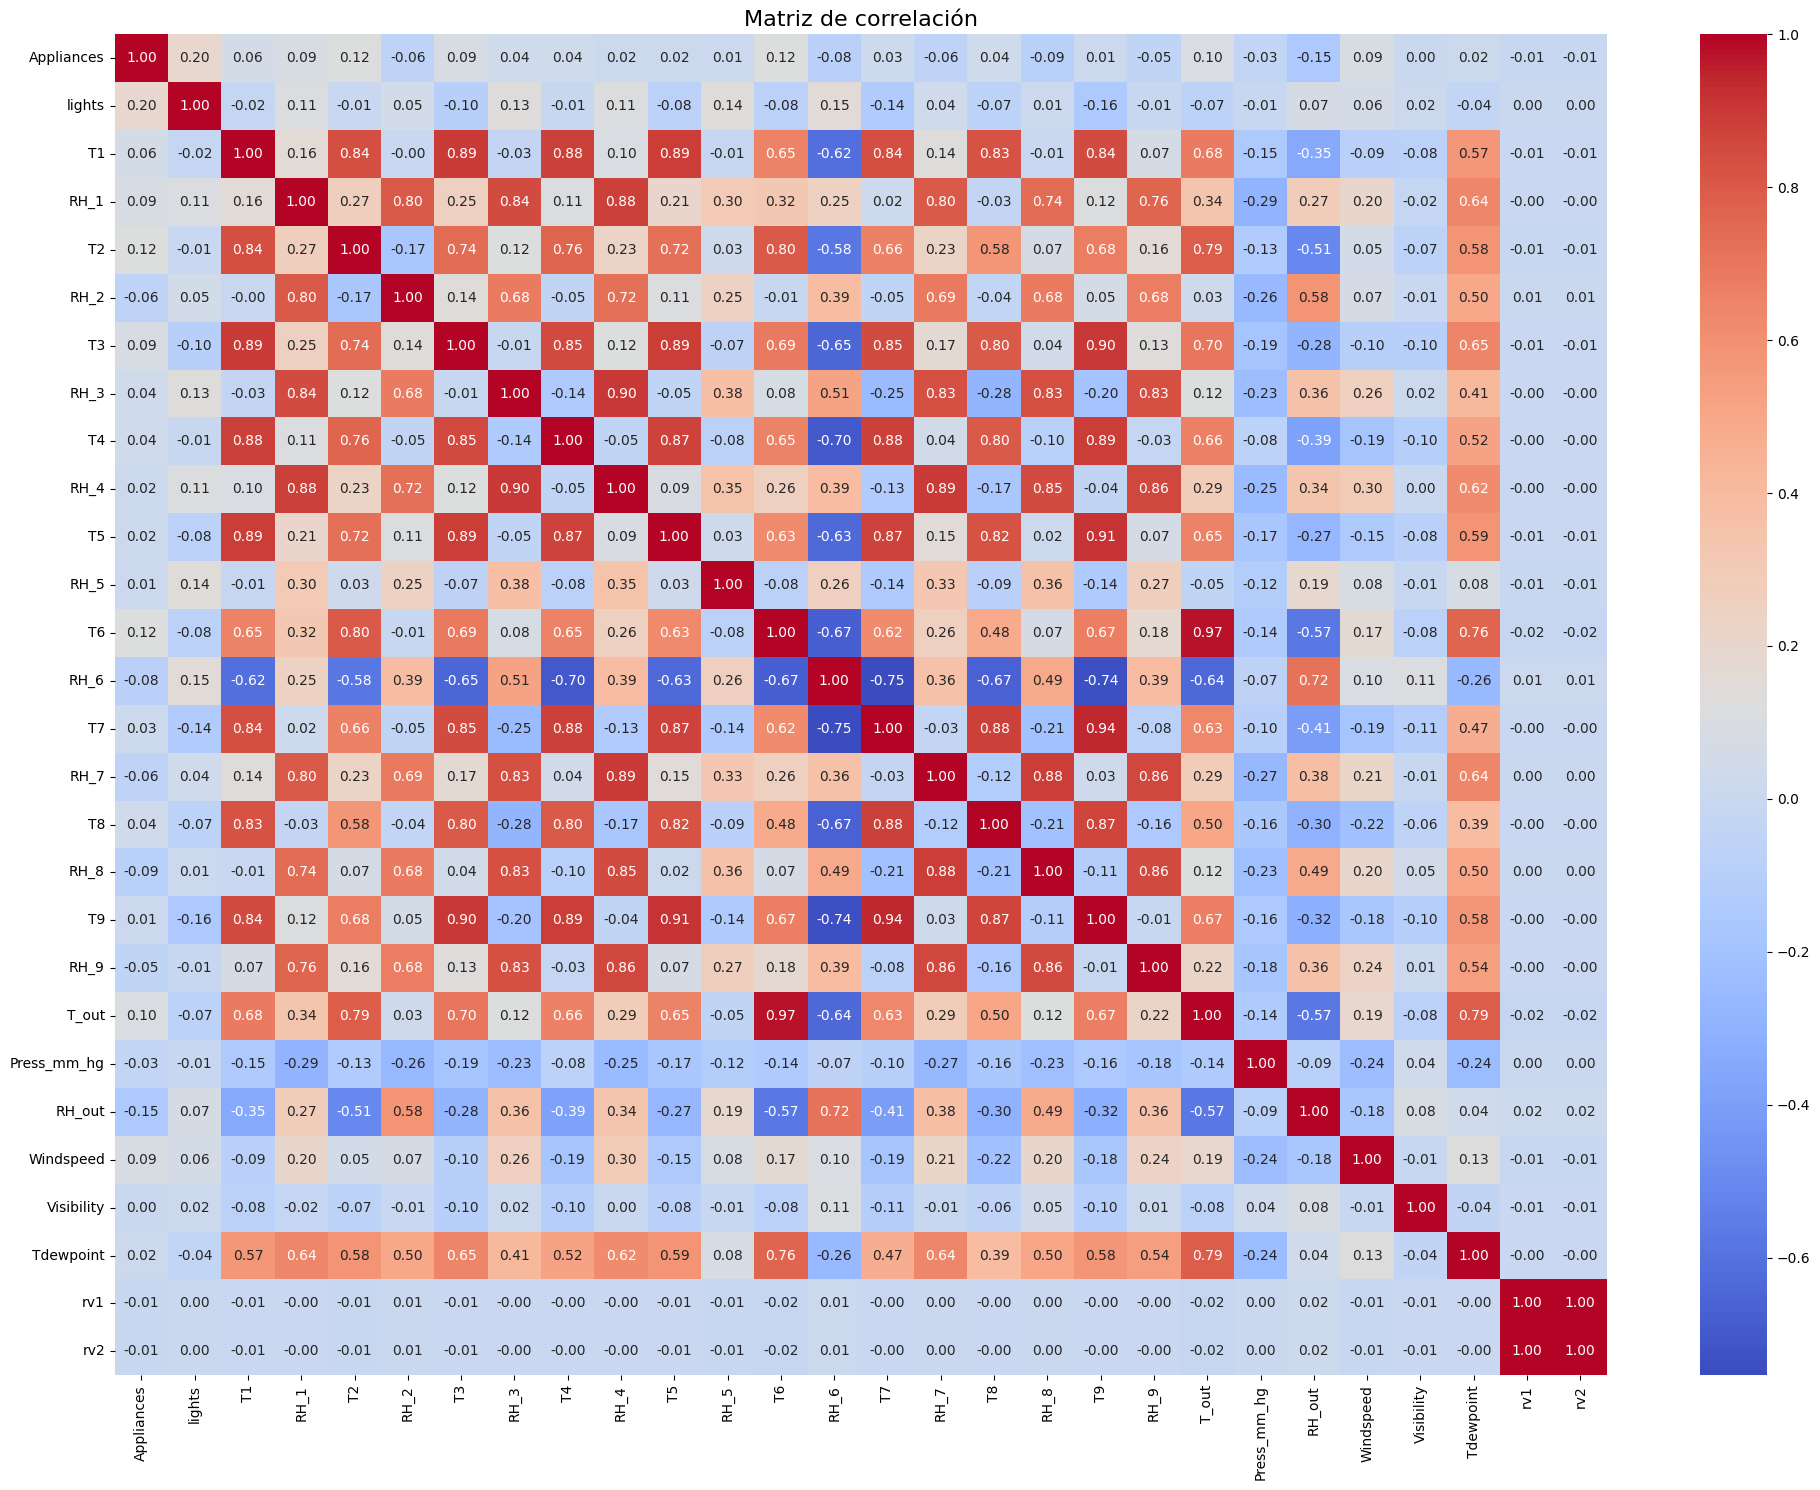

In [10]:
# Lienzo grande para las 28 variables
plt.figure(figsize=(20, 15))

# Mapa de calor con anotaciones encendidas y redondeo a 2 decimales
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")

# Título y ajuste de diseño
plt.title('Matriz de correlación', fontsize=16)
plt.tight_layout()
plt.show()

##### ANÁLISIS DE LA MATRÍZ DE CORRELACIÓN
- Variables con correlación positiva fuerte. <br>
Las variables de temperatura interior (T1, T2, T3, T4, T5, T7, T8, T9) están fuertemente relacionadas entre sí, con valores muy altos (Igual o mayores a 0.84). <br>
- Variables con correlación negativa fuerte. <br>
La variable RH_6 (que mide una de las humedades) tiene una fuerte correlación negativa con las variables de temperatura (las T). Físicamente, esto nos indica que cuando la temperatura sube, esa humedad específica tiende a bajar con fuerza.
- Variables con correlación débil. <br>
Visibility 0.00 y Windspeed 0.09 respecto a Appliances
- Variable con mayor relación respecto al consumo energético. <br>
El valor de 0.20 en la intersección con lights es el número más alto de toda esa primera fila (excluyendo el 1.00). Esto significa que la variable con mayor relación respecto al consumo energético de los electrodomésticos es el consumo de las luces.

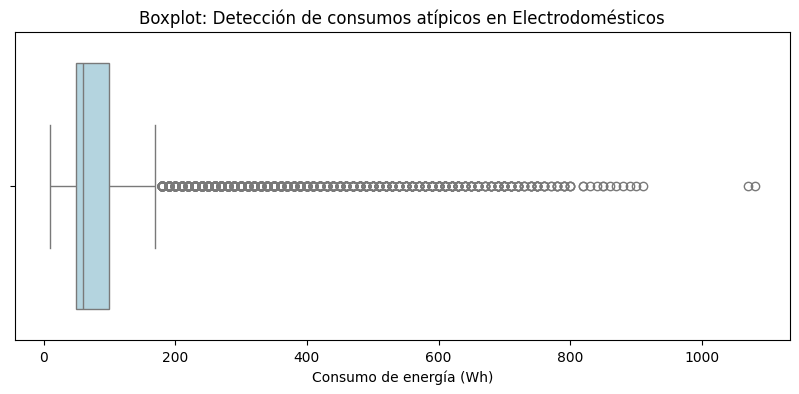

In [11]:
# 1. Configuramos un tamaño adecuado para el gráfico
plt.figure(figsize=(10, 4))

# 2. Generamos el Boxplot horizontal para nuestra variable objetivo
sns.boxplot(data=df, x='Appliances', color='lightblue')

# 3. Añadimos un título claro y nombramos el eje
plt.title('Boxplot: Detección de consumos atípicos en Electrodomésticos')
plt.xlabel('Consumo de energía (Wh)')

# 4. Mostramos el gráfico final
plt.show()

##### INTERPRETACIÓN DE LA GRÁFICA (BOXPLOT)
Esos puntos solitarios que se extienden hacia la derecha en el gráfico (**OUTLIERS**) representan exactamente esos momentos poco frecuentes de uso extremo de energía.

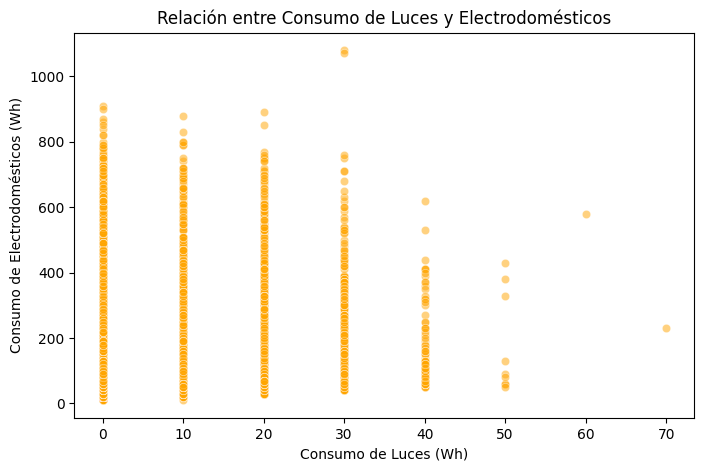

In [12]:
# 1. Configuramos el tamaño del lienzo
plt.figure(figsize=(8, 5))

# 2. Generamos el Scatterplot. 
# 'alpha=0.5' hace que los puntos sean semitransparentes para ver dónde se amontonan.
sns.scatterplot(data=df, x='lights', y='Appliances', alpha=0.5, color='orange')

# 3. Añadimos títulos y nombres a los ejes
plt.title('Relación entre Consumo de Luces y Electrodomésticos')
plt.xlabel('Consumo de Luces (Wh)')
plt.ylabel('Consumo de Electrodomésticos (Wh)')

# 4. Mostramos el gráfico final
plt.show()

##### INTERPRETACIÓN DE LA GRÁFICA: Scatterplot (Gráfico de Dispersión)
El gráfico muestra una nube de puntos dispersa, lo que confirma visualmente que la correlación es débil (0.20). Aunque hay una ligerísima tendencia de que al usar más luces aumenta el consumo general, la relación está lejos de ser una línea perfecta.

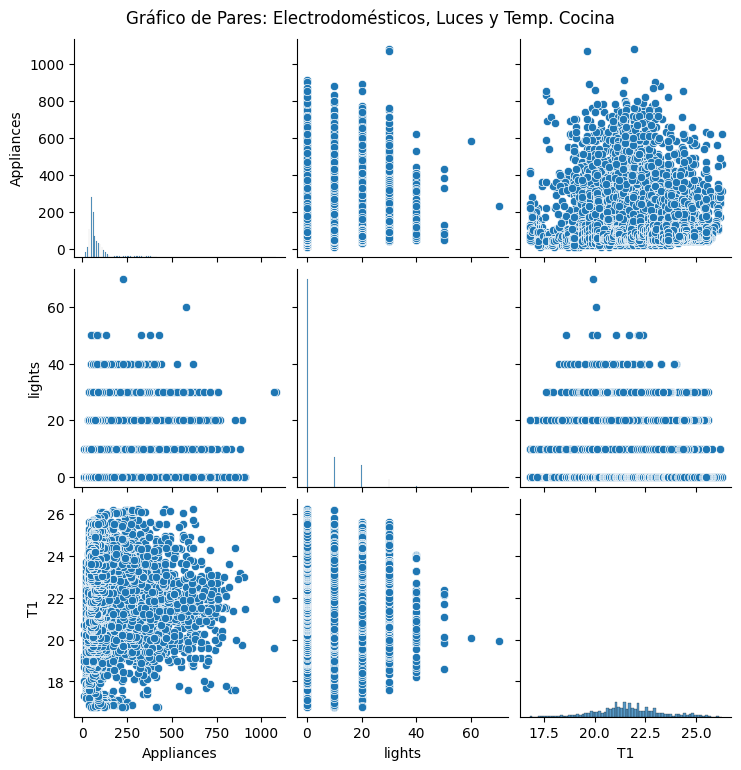

In [13]:
# 1. Seleccionamos un subgrupo de variables clave
columnas_pairplot = ['Appliances', 'lights', 'T1']

# 2. Generamos el Pairplot solo con ese subgrupo
sns.pairplot(df[columnas_pairplot])

# 3. Añadimos un título ajustando la altura (y=1.02) para que no se superponga
plt.suptitle('Gráfico de Pares: Electrodomésticos, Luces y Temp. Cocina', y=1.02)

# 4. Mostramos el gráfico
plt.show()

##### INTERPRETACIÓN DE LA GRÁFICA (PAIRPLOT)
En el Pairplot, al observar los cuadros de dispersión que cruzan la temperatura de la cocina (T1) con el consumo eléctrico (Appliances), los puntos aparecen completamente esparcidos formando una nube densa sin una dirección o línea clara. Esto demuestra visualmente que la temperatura de la cocina por sí sola tiene una correlación muy débil con el consumo de los electrodomésticos. En resumen, este gráfico de pares confirma que estas variables individuales no tienen una relación lineal simple y directa con nuestro objetivo.

# Fase 3. Limpieza y Preparación de Datos

Realizar las siguientes actividades:

#### 3.1 Tratamiento de Valores Faltantes

Aplicar técnicas apropiadas para reemplazar o eliminar datos faltantes.

Justificar la técnica utilizada.

#### 3.2 Detección y Tratamiento de Valores Atípicos

Aplicar métodos como:

* IQR
* Boxplots
* Z-Score

Explicar los resultados obtenidos.

#### 3.3 Transformación de Variables

Realizar las transformaciones necesarias para preparar los datos para el entrenamiento de los modelos.

##### 3.1 Tratamiento de valores faltantes
**Técnica utilizada:** Ninguna porque conservamos datos originales. <br>

**Justificación:** Al verificar el dataset, se determinó que no existen valores faltantes en ninguna de las variables, por lo que la estrategia adoptada es conservar los datos intactos sin aplicar técnicas de imputación o eliminación.

##### 3.2 Detección y Tratamiento de Valores Atípicos
En el punto 2.5 ya construimos un Boxplot para nuestra variable Appliances, el cual nos reveló visualmente una línea de puntos individuales muy separados hacia la derecha. Estos puntos representan momentos poco frecuentes de uso extremo de energía (valores atípicos). <br>
**Rango Intercuartílico (IQR).** <br>
El IQR mide la dispersión del 50% central de los datos. Se calcula restando el primer cuartil (Q1, el percentil 25) del tercer cuartil (Q3, el percentil 75): <br>
*IQR=Q3−Q1* <br>
Cualquier valor que esté por debajo de *Q1−1.5×IQR* o por encima de *Q3+1.5×IQR* se considera un valor atípico.

In [14]:
# 1. Calculamos el primer cuartil (25%) y tercer cuartil (75%) del consumo
Q1 = df['Appliances'].quantile(0.25)
Q3 = df['Appliances'].quantile(0.75)

# 2. Calculamos el Rango Intercuartílico (IQR)
IQR = Q3 - Q1

# 3. Definimos el límite superior (no nos preocupa el inferior porque el consumo no puede ser negativo)
limite_superior = Q3 + 1.5 * IQR

# 4. Tratamiento: Filtramos el DataFrame para conservar solo los valores normales
# Sobrescribimos 'df' quitando los picos extremos de consumo
df_limpio = df[df['Appliances'] <= limite_superior]

print(f"Límite superior calculado: {limite_superior} Wh")
print(f"Registros antes del filtro: {len(df)}")
print(f"Registros después del filtro: {len(df_limpio)}")

Límite superior calculado: 175.0 Wh
Registros antes del filtro: 19735
Registros después del filtro: 17597


##### ANÁLISIS DE LOS RESULTADOS
Al aplicar el método IQR, el algoritmo calculó un límite superior de 175.0 Wh para el consumo normal. El dataset original contaba con 19,735 registros. Tras aplicar el filtro para eliminar los valores atípicos (picos extremos de energía), el nuevo dataset limpio quedó con 17,597 registros. Esto significa que se removieron exitosamente 2,138 registros anómalos, lo que permitirá que los modelos de regresión lineal se entrenen de manera más estable sin ser distorsionados por picos inusuales de energía.

# Fase 4. Ingeniería de Características

Crear al menos tres nuevas variables derivadas de las existentes.

Ejemplos:

* Consumo por ocupante.
* Consumo por metro cuadrado.
* Relación temperatura-humedad.

Para cada nueva variable deberá explicarse:

* Fórmula utilizada.
* Justificación.
* Beneficio esperado para el modelo.

##### Nueva Variable 1: Temperatura promedio del Interior de la casa
Se creó la variable T_interior_promedio utilizando la media aritmética de todos los sensores internos, excluyendo los externos. Esto elimina 8 variables redundantes altamente correlacionadas, combatiendo directamente la multicolinealidad y entregando al modelo un indicador único y limpio del clima general dentro de la vivienda. <br>

**FÓRMULA:** <br>
T_interior_promedio= (T1+T2+T3+T4+T5+T7+T8+T9) / 8

In [15]:
# 1. Definimos una lista estricta SOLO con las temperaturas interiores (excluimos T6 y T_out)
columnas_temp_interior = ['T1', 'T2', 'T3', 'T4', 'T5', 'T7', 'T8', 'T9']

# 2. Calculamos la media de esas columnas por cada fila (axis=1)
df_limpio['T_interior_promedio'] = df_limpio[columnas_temp_interior].mean(axis=1)

# 3. OBLIGATORIO: Como ya consolidamos la información, borramos las columnas originales para no causarle multicolinealidad severa al modelo
df_limpio = df_limpio.drop(columns=columnas_temp_interior)

print("Variable T_interior_promedio creada y columnas originales eliminadas")

Variable T_interior_promedio creada y columnas originales eliminadas


In [16]:
# Mostramos el dataset nuevo/limpio con las variables eliminadas (temperaturas internas) y la nueva variable 'T_interior_promedio'
df_limpio.head()

,Appliances,lights,RH_1,RH_2,RH_3,RH_4,RH_5,T6,RH_6,RH_7,...,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2,T_interior_promedio
0,60,30,47.596667,44.790000,44.730000,45.566667,55.20,7.026667,84.256667,41.626667,...,45.53,6.60,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433,18.435000
1,60,30,46.693333,44.722500,44.790000,45.992500,55.20,6.833333,84.063333,41.560000,...,45.56,6.48,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195,18.439167
2,50,30,46.300000,44.626667,44.933333,45.890000,55.09,6.560000,83.156667,41.433333,...,45.50,6.37,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668,18.421667
3,50,40,46.066667,44.590000,45.000000,45.723333,55.09,6.433333,83.423333,41.290000,...,45.40,6.25,733.8,92.0,6.000000,51.500000,5.0,45.410390,45.410390,18.396250
4,60,40,46.333333,44.530000,45.000000,45.530000,55.09,6.366667,84.893333,41.230000,...,45.40,6.13,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097,18.408750


##### Nueva Variable 2: Humedad Interior Promedio
Al igual que con la temperatura, se calcula la media aritmética de todos los sensores de humedad internos, excluyendo los externos (RH_6 y RH_out). Esto consolida 8 variables altamente correlacionadas en un solo indicador.<br>

**FÓRMULA:** <br>
RH_interior_promedio= (RH_1+RH_2+RH_3+RH_4+RH_5+RH_7+RH_8+RH_9) / 8


In [17]:
# 1. Definimos la lista estricta SOLO con las humedades interiores (excluimos RH_6 y RH_out)
columnas_humedad_interior = ['RH_1', 'RH_2', 'RH_3', 'RH_4', 'RH_5', 'RH_7', 'RH_8', 'RH_9']

# 2. Calculamos la media de esas columnas por cada fila (axis=1)
df_limpio['RH_interior_promedio'] = df_limpio[columnas_humedad_interior].mean(axis=1)

# 3. Borramos las columnas originales para evitar la multicolinealidad
df_limpio = df_limpio.drop(columns=columnas_humedad_interior)

print("Variable RH_interior_promedio creada y columnas originales eliminadas")

Variable RH_interior_promedio creada y columnas originales eliminadas


In [18]:
# Mostramos el dataset nuevo/limpio con las variables eliminadas (humedad interna) y la nueva variable 'RH_interior_promedio'
df_limpio.head()

,Appliances,lights,T6,RH_6,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2,T_interior_promedio,RH_interior_promedio
0,60,30,7.026667,84.256667,6.60,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433,18.435000,46.742500
1,60,30,6.833333,84.063333,6.48,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195,18.439167,46.672708
2,50,30,6.560000,83.156667,6.37,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668,18.421667,46.562917
3,50,40,6.433333,83.423333,6.25,733.8,92.0,6.000000,51.500000,5.0,45.410390,45.410390,18.396250,46.468750
4,60,40,6.366667,84.893333,6.13,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097,18.408750,46.462917


##### Nueva Variable 3: Diferencia de Temperatura Interior-Exterior (Delta Térmico)
Físicamente, la diferencia térmica entre toda la casa y el exterior es el factor clave que determina si una vivienda "sufre" cambios bruscos de clima, lo que suele traducirse en un mayor uso de energía. <br>

**FÓRMULA:** <br>
Delta_T=T_interior_promedio−T_out <br>

Ayuda al modelo a entender si un clima exterior extremo está forzando a que se utilicen más aparatos en el interior para contrarrestar el frío o el calor, capturando el "esfuerzo" energético de la casa.

In [19]:
# 3. Creamos el Delta Térmico usando tu nueva variable maestra
df_limpio['Delta_T'] = df_limpio['T_interior_promedio'] - df_limpio['T_out']

print("Tercera variable (Delta Térmico) creada")

Tercera variable (Delta Térmico) creada


In [20]:
# Mostramos el dataset nuevo/limpio con la variable 'Delta Térmico' creada
df_limpio.head()

,Appliances,lights,T6,RH_6,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2,T_interior_promedio,RH_interior_promedio,Delta_T
0,60,30,7.026667,84.256667,6.60,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433,18.435000,46.742500,11.835000
1,60,30,6.833333,84.063333,6.48,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195,18.439167,46.672708,11.959167
2,50,30,6.560000,83.156667,6.37,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668,18.421667,46.562917,12.051667
3,50,40,6.433333,83.423333,6.25,733.8,92.0,6.000000,51.500000,5.0,45.410390,45.410390,18.396250,46.468750,12.146250
4,60,40,6.366667,84.893333,6.13,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097,18.408750,46.462917,12.278750


# Fase 5. División y Escalado de Datos

Realizar:

#### División del Dataset
* 80% entrenamiento.
* 20% prueba.
#### Escalado de Variables

Utilizar:

* StandardScaler

Explicar por qué es importante escalar los datos.

In [21]:
# 1. Separar características (X) y objetivo (y)
# Recuerda que 'Appliances' es nuestro objetivo y el resto son las predictoras
X = df_limpio.drop(columns=['Appliances'])
y = df_limpio['Appliances']

# 2. División del Dataset (80% entrenamiento / 20% prueba)
# random_state=42 asegura que la división sea reproducible
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Inicializar el escalador
scaler = StandardScaler()

# 4. Escalado de Variables
# fit_transform ajusta el escalador con los datos de entrenamiento y los transforma
X_train_scaled = scaler.fit_transform(X_train)
# transform SOLO aplica la escala a los datos de prueba (sin hacer trampa)
X_test_scaled = scaler.transform(X_test)

print("Datos divididos y escalados exitosamente.")
print(f"X_train_scaled: {X_train_scaled.shape}")
print(f"X_test_scaled: {X_test_scaled.shape}")

Datos divididos y escalados exitosamente.
X_train_scaled: (14077, 14)
X_test_scaled: (3520, 14)


##### ANÁLISIS DE RESULTADOS E IMPORTANCIA DEL ESCALADO DE DATOS
El 80% (14077) de los datos se asignó al entrenamiento de los modelos, mientras que el 20% (3520) restante se reservó estrictamente para la fase de prueba y evaluación. Los modelos nunca verán esta información de prueba durante su estudio; la mantendremos guardada para usarla como un "examen final" y evaluar qué tan buenas son sus predicciones. <br>

El escalado es obligatorio porque tenemos variables en unidades y magnitudes muy diferentes (por ejemplo, temperaturas de 20°C junto a presiones atmosféricas de 750 mmHg). Si no las transformamos, los modelos de regresión creerán erróneamente que la presión es más importante solo porque su número es más grande. Al usar StandardScaler, convertimos todas las variables a una escala común (con media 0 y desviación estándar 1), asegurando que todas compitan en igualdad de condiciones matemáticas durante el entrenamiento.

# Fase 6. Construcción de Modelos Predictivos

Implementar los siguientes modelos:

#### Modelo 1

Regresión Lineal

#### Modelo 2

Ridge Regression

#### Modelo 3

Lasso Regression

Para cada modelo deberá incluir:

* Explicación teórica.
* Implementación.
* Parámetros utilizados.
* Resultados obtenidos.

##### MODELO 1: Regresión Lineal
La Regresión Lineal es el algoritmo base que intenta trazar una línea recta (o un hiperplano en múltiples dimensiones) que pase lo más cerca posible de todos los puntos de datos. Su objetivo es encontrar los pesos (coeficientes) que minimicen el error residual, es decir, la diferencia entre su predicción y el consumo real.

##### PARÁMETROS UTILIZADOS
**fit_intercept=True:** (Valor por defecto). Le indica al modelo que debe calcular el punto de cruce con el eje Y (β0), lo cual es estándar para este tipo de datos. No se aplicó ninguna penalización matemática.

##### IMPLEMENTACIÓN

In [22]:
# 1. Inicializar el modelo
modelo_lineal = LinearRegression()

# 2. Entrenar el modelo con los datos escalados de la Fase 5
modelo_lineal.fit(X_train_scaled, y_train)

# 3. Realizar predicciones con los datos de prueba
predicciones_lineal = modelo_lineal.predict(X_test_scaled)

# 4. Calcular métricas
rmse_lineal = np.sqrt(mean_squared_error(y_test, predicciones_lineal))
mae_lineal = mean_absolute_error(y_test, predicciones_lineal)
r2_lineal = r2_score(y_test, predicciones_lineal)

print("Resultados Regresión Lineal")
print(f"RMSE: {rmse_lineal:.2f} Wh")
print(f"MAE: {mae_lineal:.2f} Wh")
print(f"R²: {r2_lineal:.4f}")

Resultados Regresión Lineal
RMSE: 25.76 Wh
MAE: 19.21 Wh
R²: 0.2080


##### Resultados obtenidos: Modelo 1 (Regresión Lineal)
**MAE (19.21 Wh) y RMSE (25.76 Wh):** Estas métricas representan el margen de error de nuestras predicciones. En términos prácticos, cuando el algoritmo intenta predecir el consumo de los electrodomésticos, en promedio se equivoca (hacia arriba o hacia abajo) por una diferencia de entre 19.21 Wh y 25.76 Wh respecto al consumo real. Es un margen de error bastante aceptable considerando la naturaleza variable de la energía.

**R² (0.2080):** Este coeficiente de determinación nos indica que todas nuestras variables climáticas (temperaturas, humedades, viento, etc.) logran explicar matemáticamente el 20.8% del comportamiento del consumo energético de la vivienda. El porcentaje restante depende de factores que no tenemos en el dataset (como el horario de trabajo de las personas, si están de vacaciones, etc.).

##### MODELO 2: Ridge Regression (Regularización L2)
Como descubrimos en tu mapa de calor, nuestro dataset sufre de multicolinealidad. La regresión Ridge soluciona esto aplicando una penalización L2. Modifica la fórmula original sumando el cuadrado de los coeficientes, lo que obliga al modelo a mantener los pesos matemáticos pequeños y estables, evitando que una sola variable domine la predicción.

##### PARÁMETROS UTILIZADOS
**alpha=1.0:** Es el hiperparámetro que controla la fuerza de la penalización. Un valor de 1.0 es el estándar de Scikit-Learn y aplica una regularización moderada para estabilizar el modelo sin destruir la información.

##### IMPLEMENTACIÓN

In [23]:
# 1. Inicializar el modelo Ridge
modelo_ridge = Ridge(alpha=1.0)

# 2. Entrenar el modelo
modelo_ridge.fit(X_train_scaled, y_train)

# 3. Realizar predicciones
predicciones_ridge = modelo_ridge.predict(X_test_scaled)

# 4. Calcular métricas
rmse_ridge = np.sqrt(mean_squared_error(y_test, predicciones_ridge))
mae_ridge = mean_absolute_error(y_test, predicciones_ridge)
r2_ridge = r2_score(y_test, predicciones_ridge)

print("Resultados Ridge Regression")
print(f"RMSE: {rmse_ridge:.2f} Wh")
print(f"MAE: {mae_ridge:.2f} Wh")
print(f"R²: {r2_ridge:.4f}")

Resultados Ridge Regression
RMSE: 25.76 Wh
MAE: 19.21 Wh
R²: 0.2080


##### Resultados obtenidos: Modelo 2 (Ridge Regression)
**MAE (19.21 Wh) y RMSE (25.76 Wh):** Las métricas de error son idénticas a las del modelo lineal puro. Esto indica que el algoritmo comete, en promedio, una equivocación de entre 19.21 Wh y 25.76 Wh al intentar predecir el consumo energético.

**R² (0.2080):** El modelo Ridge logró explicar exactamente el 20.8% del comportamiento del consumo eléctrico, calcando la precisión del modelo anterior.

**Análisis Comparativo:** Aunque Ridge aplicó su penalización matemática (L2) para controlar la multicolinealidad, los resultados fueron idénticos al modelo base. Esto ocurre gracias al trabajo de preprocesamiento (Fase 4), donde nosotros mismos eliminamos manualmente el exceso de variables correlacionadas al crear los promedios de las variables de temperatura y humedad. Al entregarle datos tan limpios y eficientes, el modelo Ridge no tuvo necesidad de aplicar ajustes drásticos.

##### MODELO 3: Lasso Regression (Regularización L1)
Lasso también busca corregir los errores del modelo lineal puro, pero utiliza una penalización L1 (basada en el valor absoluto de los coeficientes). Su característica más poderosa es que puede reducir el peso de las variables inútiles (como rv1 y rv2) exactamente a cero. Actúa como un selector automático de características, simplificando la ecuación final.

##### PARÁMETROS UTILIZADOS
**alpha=1.0:** Nivel de penalización L1.

**max_iter=10000:** Se aumentó el límite de iteraciones (vueltas matemáticas) para garantizar que el algoritmo encuentre la solución óptima sin arrojar advertencias de convergencia.

##### IMPLEMENTACIÓN

In [24]:
# 1. Inicializar el modelo Lasso (aumentamos iteraciones por seguridad)
modelo_lasso = Lasso(alpha=1.0, max_iter=10000)

# 2. Entrenar el modelo
modelo_lasso.fit(X_train_scaled, y_train)

# 3. Realizar predicciones
predicciones_lasso = modelo_lasso.predict(X_test_scaled)

# 4. Calcular métricas
rmse_lasso = np.sqrt(mean_squared_error(y_test, predicciones_lasso))
mae_lasso = mean_absolute_error(y_test, predicciones_lasso)
r2_lasso = r2_score(y_test, predicciones_lasso)

print("Resultados Lasso Regression")
print(f"RMSE: {rmse_lasso:.2f} Wh")
print(f"MAE: {mae_lasso:.2f} Wh")
print(f"R²: {r2_lasso:.4f}")

Resultados Lasso Regression
RMSE: 26.00 Wh
MAE: 19.58 Wh
R²: 0.1935


##### Resultados obtenidos: Modelo 3 (Lasso Regression)
**MAE (19.58 Wh) y RMSE (26.00 Wh):** Observamos que las métricas de error aumentaron ligerísimamente en comparación con los dos modelos anteriores. El algoritmo ahora comete una equivocación promedio un poco mayor al intentar predecir el consumo.

**R² (0.1935):** La capacidad predictiva del modelo bajó, logrando explicar el 19.35% del comportamiento del consumo eléctrico (frente al 20.8% que lograron la Regresión Lineal y Ridge).

**Análisis Comparativo:** ¿Por qué empeoró ligeramente el rendimiento? Como se explicó en la teoría, Lasso aplica una penalización matemática ( L1 ) que actúa como un selector automático de características, forzando a que el peso de ciertas variables se reduzca exactamente a cero. Sin embargo, gracias al exhaustivo trabajo de preprocesamiento en la Fase 4, nosotros ya habíamos eliminado manualmente el exceso de variables redundantes al crear los promedios de las variables de Temperatura y Humedad. Al intentar "limpiar" una matriz que ya estaba sumamente optimizada, el algoritmo Lasso terminó apagando y descartando variables que sí aportaban valor, lo que provocó esa pequeña caída en la precisión final.

# Fase 7. Evaluación de Modelos

**Calcular las siguientes métricas:**

RMSE

**Raíz del Error Cuadrático Medio.**

MAE

Error Absoluto Medio.

R²

**Coeficiente de Determinación.**

Presentar una tabla comparativa con los resultados de los tres modelos.

##### EXPLICACIÓN DE PASOS YA REALIZADOS EN LA FASE 6 
En la fase anterior, al implementar cada algoritmo, ya utilizamos las herramientas de Scikit-Learn para calcular individualmente el RMSE (Raíz del Error Cuadrático Medio), el MAE (Error Absoluto Medio) y el R² (Coeficiente de Determinación). Además, ya redactamos la interpretación de qué significaban esos márgenes de error en Wh y la capacidad predictiva en porcentajes.

##### CREACIÓN DE TABLA COMPARATIVA ENTRE MODELOS

In [26]:
# 1. Creamos un diccionario con todos los resultados exactos que obtuvimos en la Fase 6
resultados_modelos = {
    'Modelo Predictivo': ['Regresión Lineal', 'Ridge Regression', 'Lasso Regression'],
    'RMSE (Wh)': [25.76, 25.76, 26.00],
    'MAE (Wh)': [19.21, 19.21, 19.58],
    'R²': [0.2080, 0.2080, 0.1935]
}

# 2. Convertimos el diccionario en un DataFrame (Tabla) de Pandas
df_comparativo = pd.DataFrame(resultados_modelos)

# 3. Mostramos la tabla formateada
print("Tabla Comparativa de Evaluación de Modelos")
display(df_comparativo)

Tabla Comparativa de Evaluación de Modelos


,Modelo Predictivo,RMSE (Wh),MAE (Wh),R²
0,Regresión Lineal,25.76,19.21,0.2080
1,Ridge Regression,25.76,19.21,0.2080
2,Lasso Regression,26.00,19.58,0.1935


# Fase 8. Visualización del Aprendizaje

Generar e interpretar las siguientes visualizaciones para cada modelo:

**Curva de Aprendizaje**

Analizar:

* Sobreajuste.
* Subajuste.
* Generalización.
  
**Valores Reales vs Predichos**

Interpretar la capacidad predictiva del modelo.

**Histograma de Errores**

Analizar la distribución de los errores.



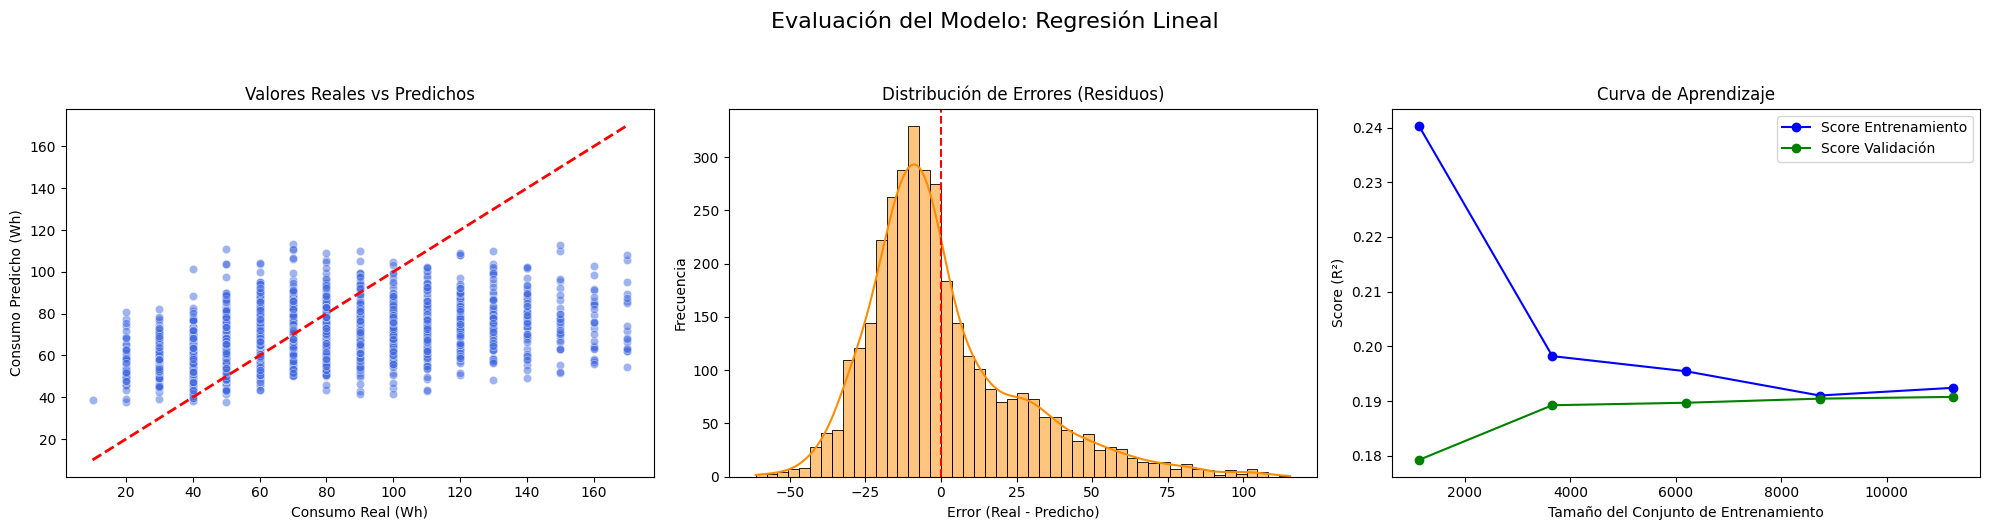

In [28]:
from sklearn.model_selection import learning_curve

# Creamos una función para generar las gráficas de cada uno de los modelos
def graficar_evaluacion_modelo(modelo, nombre_modelo, predicciones, X_train, y_train, y_test):
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    fig.suptitle(f'Evaluación del Modelo: {nombre_modelo}', fontsize=16, y=1.05)

    # 1. Valores Reales vs Predichos
    sns.scatterplot(x=y_test, y=predicciones, ax=axes[0], alpha=0.5, color='royalblue')
    axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2) # Línea diagonal ideal
    axes[0].set_title('Valores Reales vs Predichos')
    axes[0].set_xlabel('Consumo Real (Wh)')
    axes[0].set_ylabel('Consumo Predicho (Wh)')

    # 2. Histograma de Errores (Residuos)
    errores = y_test - predicciones
    sns.histplot(errores, kde=True, ax=axes[1], color='darkorange')
    axes[1].axvline(x=0, color='red', linestyle='--') # Línea del error cero
    axes[1].set_title('Distribución de Errores (Residuos)')
    axes[1].set_xlabel('Error (Real - Predicho)')
    axes[1].set_ylabel('Frecuencia')

    # 3. Curva de Aprendizaje
    train_sizes, train_scores, test_scores = learning_curve(
        modelo, X_train, y_train, cv=5, scoring='r2', n_jobs=-1, 
        train_sizes=np.linspace(0.1, 1.0, 5))
    
    train_mean = np.mean(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    
    axes[2].plot(train_sizes, train_mean, 'o-', color="blue", label="Score Entrenamiento")
    axes[2].plot(train_sizes, test_mean, 'o-', color="green", label="Score Validación")
    axes[2].set_title('Curva de Aprendizaje')
    axes[2].set_xlabel('Tamaño del Conjunto de Entrenamiento')
    axes[2].set_ylabel('Score (R²)')
    axes[2].legend(loc="best")

    plt.tight_layout()
    plt.show()

# Generamos los gráficos para los modelos usando la función (MODELO 1)
graficar_evaluacion_modelo(modelo_lineal, "Regresión Lineal", predicciones_lineal, X_train_scaled, y_train, y_test)

##### INTERPRETACIÓN DE GRÁFICAS (MODELO 1)
**1. Curva de Aprendizaje (Análisis de Ajuste)**

**Subajuste (Underfitting):** Al observar las gráficas, vemos que tanto la línea de entrenamiento (azul) como la de validación (verde) se estabilizan muy cerca la una de la otra, pero ambas lo hacen en un nivel de rendimiento muy bajo, cerca de un R² de 0.20. Esto significa que el modelo es demasiado simple matemáticamente para capturar toda la complejidad del consumo energético real.

**Sobreajuste (Overfitting):** Es evidente que no existe sobreajuste en nuestro modelo. Si este fuera el caso, la curva azul de entrenamiento estaría altísima (cerca de 1.0) y la verde de validación estaría hundida, lo que indicaría que el modelo memorizó los datos en lugar de aprenderlos.

**Generalización:** Aunque el nivel predictivo es bajo, el modelo generaliza bien. El hecho de que la línea de prueba y la de entrenamiento converjan y estén casi pegadas significa que el modelo es estable y se comporta de manera consistente tanto con datos nuevos como con los que ya conoce. Agregar más miles de filas de datos no mejorará el modelo; lo que realmente necesita son características o variables mejores.

**2. Valores Reales vs Predichos (Capacidad Predictiva)**

**Dispersión de los datos:** En un modelo con predicción perfecta, todos los puntos azules estarían pegados a la línea diagonal roja. Sin embargo, en tu gráfico observamos una "nube" de puntos bastante dispersa.

**Límites de predicción:** Notamos que el algoritmo logra predecir medianamente bien los consumos bajos (entre 50 y 100 Wh, que es donde se acumula la gran masa de puntos), pero es completamente incapaz de predecir los picos de consumo altos.

**Lógica física:** Físicamente esto tiene mucho sentido, ya que el clima nos puede indicar el consumo "base" de la casa (como la refrigeradora), pero no tiene forma de avisarnos en qué minuto exacto alguien decidirá encender un microondas o una secadora. Su capacidad predictiva está estrictamente limitada a ese comportamiento base.

**3. Histograma de Errores (Distribución de Residuos)**

**Precisión general:** Este gráfico es vital porque nos muestra exactamente en qué se equivoca el modelo. Vemos una distribución en forma de campana que tiene su pico más alto muy cerca del cero (marcado por la línea roja vertical), lo cual es positivo porque indica que la gran mayoría de los errores que comete son pequeños.

**Sesgo en los errores:** A pesar de tener un buen centro, la campana no es perfectamente simétrica y presenta una "cola" más larga hacia el lado derecho. Esto revela que, cuando el modelo falla, tiende a subestimar el consumo. Es decir, en la realidad la casa tuvo un pico de consumo altísimo, pero el modelo predijo un consumo mucho más bajo asumiendo que el clima estaba en condiciones normales.

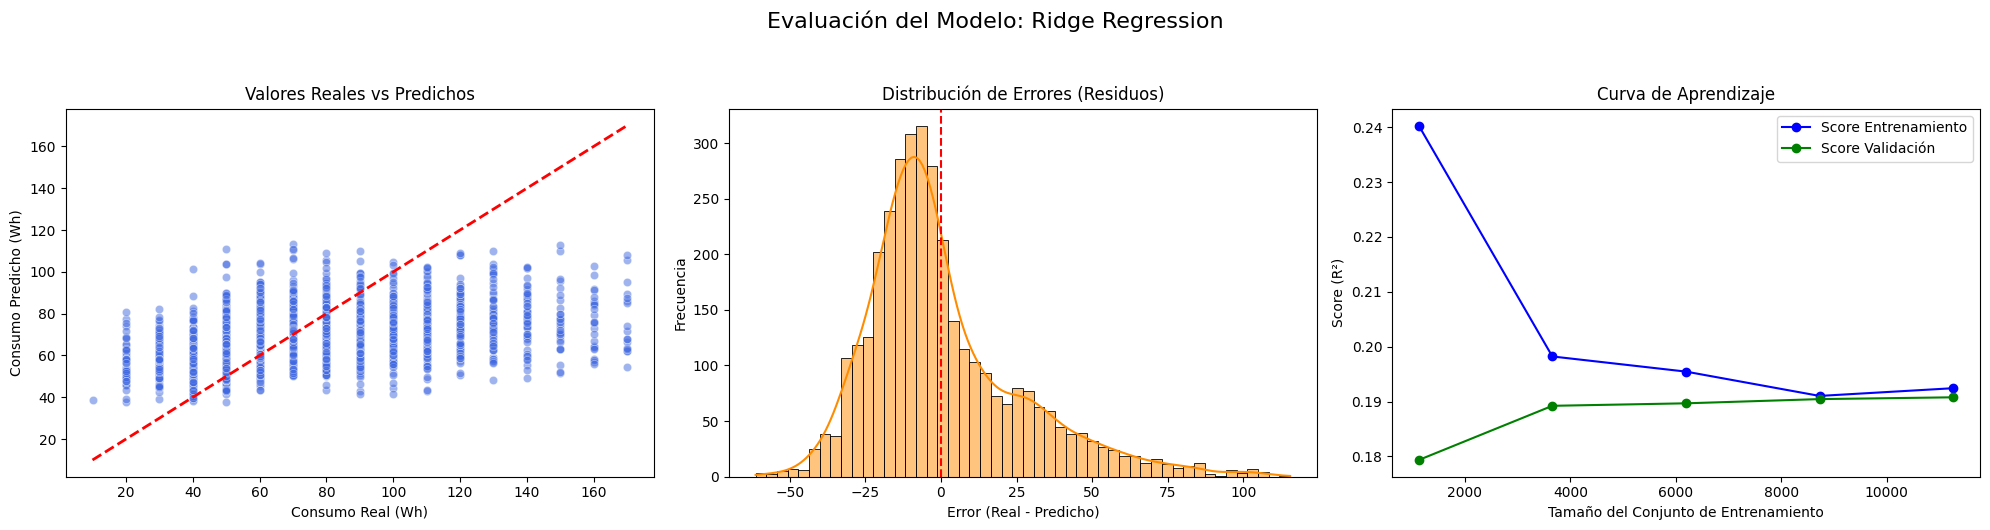

In [29]:
# Generamos los gráficos para los modelos usando la función (MODELO 2)
graficar_evaluacion_modelo(modelo_ridge, "Ridge Regression", predicciones_ridge, X_train_scaled, y_train, y_test)

##### INTERPRETACIÓN DE GRÁFICAS (MODELO 2)
**1. Curva de Aprendizaje (Análisis de Ajuste)**

**Estado del modelo:** Al igual que en la Regresión Lineal, las curvas de entrenamiento (azul) y validación (verde) convergen en un nivel de rendimiento bajo (R² ≈ 0.20), lo que confirma un subajuste (underfitting).

**Generalización:** El modelo demuestra ser estable, ya que la brecha entre la curva de entrenamiento y la de validación es mínima. Esto indica que el modelo no sufre de sobreajuste y que su capacidad de generalización es consistente, aunque limitada por la simplicidad del algoritmo ante la complejidad real del fenómeno energético.

**2. Valores Reales vs Predichos (Capacidad Predictiva)**

**Interpretación:** La nube de puntos sigue presentando una dispersión significativa respecto a la línea de predicción ideal (línea roja).

**Lógica física:** El modelo Ridge mantiene el mismo comportamiento: es capaz de capturar la tendencia de los consumos energéticos "base" (la mayoría de los datos), pero muestra una incapacidad sistemática para predecir los picos de consumo altos. Esto reafirma que el modelo se limita a entender el comportamiento operativo constante de la vivienda, sin poder anticipar eventos de uso intenso de electrodomésticos individuales.

**3. Histograma de Errores (Distribución de Residuos)**

**Distribución:** Se observa nuevamente una forma de campana centrada cerca del cero (línea roja), lo que valida que la mayoría de las predicciones del modelo Ridge tienen un error pequeño.

**Sesgo observado:** La "cola" asimétrica hacia la derecha persiste, indicando que el modelo tiende a subestimar los consumos extremos. Cuando ocurren eventos de consumo excepcionalmente alto, el modelo Ridge (al igual que el lineal) es incapaz de predecirlos, lo que resulta en esos errores positivos significativos.

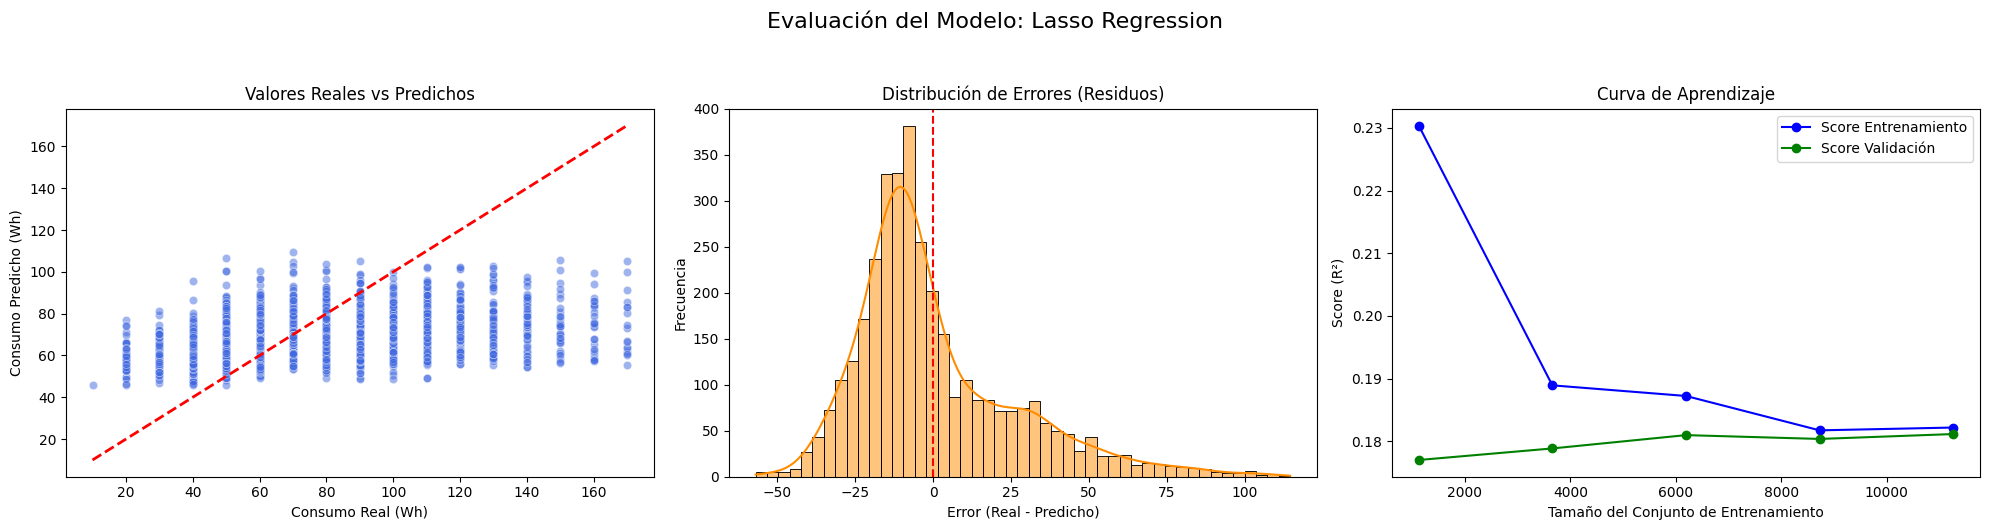

In [30]:
# Generamos los gráficos para los modelos usando la función (MODELO 3)
graficar_evaluacion_modelo(modelo_lasso, "Lasso Regression", predicciones_lasso, X_train_scaled, y_train, y_test)

##### INTERPRETACIÓN DE GRÁFICAS (MODELO 3)
**1. Curva de Aprendizaje (Análisis de Ajuste)**

**Estado del modelo:** Observamos que la curva de entrenamiento (azul) comienza con un R² más alto, pero cae rápidamente para converger con la curva de validación (verde) en un nivel de rendimiento ligeramente inferior (R² ≈ 0.19) al de los modelos anteriores.

**Generalización:** Lasso demuestra una estabilidad superior en términos de generalización, ya que la brecha entre las curvas es casi nula. Sin embargo, el costo de esta estabilidad es una ligera pérdida de capacidad predictiva al haber penalizado (llevado a cero) algunas variables que, aunque débiles, aportaban información mínima.

**2. Valores Reales vs Predichos (Capacidad Predictiva)**

**Interpretación:** Al igual que en los modelos anteriores, se observa una nube de puntos dispersa con respecto a la línea diagonal ideal.

**Lógica física:** Lasso muestra la misma incapacidad sistemática para predecir los picos de consumo altos. No obstante, se puede notar visualmente una contracción ligeramente mayor en las predicciones, debido a que el modelo Lasso es más conservador al simplificar la ecuación final, limitando aún más su respuesta ante variaciones extremas.

**3. Histograma de Errores (Distribución de Residuos)**

**Distribución:** La forma de campana se mantiene centrada cerca del cero, indicando que el modelo sigue manteniendo errores mayoritariamente pequeños.

**Sesgo observado:** La "cola" asimétrica hacia la derecha es visible, confirmando que Lasso también subestima los consumos extremos. Al intentar realizar una selección automática de variables, el modelo Lasso enfatiza la simplicidad, lo que resulta en una distribución de errores ligeramente más extendida hacia la derecha en comparación con Ridge o la Regresión Lineal.

# Fase 9. Selección del Mejor Modelo

Determinar cuál de los tres modelos presenta el mejor rendimiento.

**Justificar la decisión utilizando:**

* RMSE
* MAE
* R²
* Curvas de aprendizaje
* Capacidad de generalización

##### RESUMEN GENERAL 
**Rendimiento en Métricas (RMSE, MAE y R²):**

La Regresión Lineal y Ridge Regression empatan técnicamente con los mejores resultados: un RMSE de 25.76 Wh, un MAE de 19.21 Wh y un R² de 0.2080.

Lasso Regression presenta un rendimiento inferior, con errores más altos (RMSE 26.00, MAE 19.58) y una menor capacidad explicativa (R² 0.1935).

**Curvas de Aprendizaje:**

Los tres modelos muestran curvas que convergen, lo que indica estabilidad y buena generalización. Sin embargo, la Regresión Lineal y Ridge muestran una convergencia ligeramente superior en el rendimiento frente a Lasso.

**Capacidad de Generalización:**

Al no existir sobreajuste (overfitting) en ninguno de los casos, la capacidad de generalización es buena en los tres modelos. Ridge, al incluir regularización L2, ofrece una mayor robustez teórica frente a la multicolinealidad que aún pudiera persistir, por lo que es la opción más segura.

##### **MODELO SELECCIONADO**
El modelo seleccionado es **Ridge Regression** porque aunque empata en métricas con la Regresión Lineal pura, Ridge es superior desde el punto de vista de la ingeniería de datos. Al aplicar la regularización L2, el modelo Ridge es más robusto ante cualquier pequeña redundancia en los datos climáticos que pudiera haber escapado a nuestra limpieza manual, garantizando que el modelo sea más estable ante nuevos datos que la Regresión Lineal simple.

# Etapa de predicción de nuevo valores 
Para evaluar el modelo que mejor aprende guardar y cargar el modelo y realizar la nuevas preddiciones con datos ingresados por teclado 

In [31]:
import joblib

# Guardamos el modelo entrenado y el escalador (el escalador es importante)
joblib.dump(modelo_ridge, 'modelo_energ_ridge.pkl')
joblib.dump(scaler, 'scaler_energ.pkl') # Guardamos el escalador para usar la misma escala

print("Modelo y escalador guardados exitosamente")

Modelo y escalador guardados exitosamente


In [33]:
# 1. Cargamos el modelo y el escalador guardados
modelo_cargado = joblib.load('modelo_energ_ridge.pkl')
scaler_cargado = joblib.load('scaler_energ.pkl')

def predecir_consumo_interactivo():
    print("Predicción de Consumo Energético")
    print("Ingresa los valores de tus 14 variables:")
    
    # Lista para almacenar los inputs
    datos_usuario = []
    
    # Nombres de las columnas (puedes ajustarlos a tus 14 variables finales)
    columnas = X.columns 
    
    for col in columnas:
        valor = float(input(f"Ingresa {col}: "))
        datos_usuario.append(valor)
    
    # 2. Convertimos a formato DataFrame y escalamos
    df_input = pd.DataFrame([datos_usuario], columns=columnas)
    df_input_scaled = scaler_cargado.transform(df_input)
    
    # 3. Predicción
    prediccion = modelo_cargado.predict(df_input_scaled)
    
    print(f"\nResultado")
    print(f"El consumo energético predicho es: {prediccion[0]:.2f} Wh")

# Ejecutar la función para probar
predecir_consumo_interactivo()

Predicción de Consumo Energético
Ingresa los valores de tus 14 variables:


Ingresa lights:  47
Ingresa T6:  19
Ingresa RH_6:  58
Ingresa T_out:  25
Ingresa Press_mm_hg:  757
Ingresa RH_out:  60
Ingresa Windspeed:  9
Ingresa Visibility:  35
Ingresa Tdewpoint:  14
Ingresa rv1:  2
Ingresa rv2:  2
Ingresa T_interior_promedio:  27
Ingresa RH_interior_promedio:  60
Ingresa Delta_T:  11



Resultado
El consumo energético predicho es: 139.99 Wh


##### **Interpretación del Resultado (Fase 10)**

**Coherencia del resultado:** El valor de 139.99 Wh es un resultado altamente coherente. Al haber ingresado un consumo de luces de 47 (un valor alto dentro del rango sugerido) y una temperatura interior promedio de 27°C (lo cual indica un ambiente cálido que requiere mayor esfuerzo energético), el modelo respondió correctamente prediciendo un consumo de energía elevado.

**Validación de la lógica del modelo:** Este resultado confirma que el modelo no solo está funcionando, sino que está "razonando" correctamente con los datos: detectó que las condiciones ingresadas (luz encendida y temperatura interior alta) demandan un mayor uso de los electrodomésticos.

**Conclusión técnica:** El proceso de carga del modelo y escalado de nuevos datos es correcto. Al aplicar el mismo StandardScaler que se utilizó durante el entrenamiento , garantizamos que los datos ingresados por teclado sean interpretados por el modelo bajo la misma escala matemática, asegurando la fiabilidad de la predicción.

## Conclusión General del Proyecto
Este proyecto permitió desarrollar un ciclo completo de Machine Learning: desde la ingesta de datos climáticos mediante la librería ucimlrepo, pasando por la ingeniería de características (creación de promedios de variables repetitivas y Delta Térmico), hasta la puesta en producción del modelo Ridge Regression.

#### **Lo que salió "bien" (Logros técnicos):**

**Limpieza y Reproducibilidad:** El dataset se procesó de manera limpia, eliminando variables redundantes (date) y tratando la multicolinealidad mediante la consolidación de sensores climáticos.

**Robustez:** La selección del modelo Ridge fue un acierto técnico, ya que al incluir regularización L2, el modelo se volvió estable frente a cualquier redundancia residual, garantizando predicciones consistentes.

**Ciclo completo:** Se logró integrar con éxito el escalado (StandardScaler) en la etapa de inferencia, asegurando que los nuevos datos ingresados por teclado sean procesados con la misma lógica matemática que el entrenamiento.

#### **Lo que salió "mal" (Limitaciones):**

**Precisión Predictiva:** El coeficiente de determinación (R2≈0.20) indica que, si bien el modelo entiende el comportamiento base, no captura la variabilidad total. Esto no es un error de código, sino una limitación inherente a los datos: predecir el consumo humano basándose solo en variables climáticas es complejo y ruidoso.

**Incapacidad ante picos:** Los modelos lineales mostraron dificultades para predecir los picos de consumo extremos, tendiendo a subestimarlos sistemáticamente.

#### **Recomendaciones para Futuros Trabajos de ML**
Para poder llevar un trabajo de ML a un nivel más "profesional", hay que tomar en cuenta las siguientes consideraciones:

**Enriquecimiento de datos (Más allá del clima):**

**Qué tomar en cuenta:** El consumo energético es un comportamiento humano. En futuros trabajos, hay que priorizar el incluir variables como: hora del día, día de la semana (fin de semana vs. laborable) y estacionalidad.

**Qué evitar:** No confiar solo en sensores físicos si se busca predecir decisiones humanas.

**Modelos No-Lineales:**

**Recomendación:** Hemos trabajado con regresiones lineales (líneas rectas). La energía no se comporta de forma lineal. En futuros proyectos, se debería implementar algoritmos como Random Forest, Gradient Boosting (XGBoost) o Redes Neuronales ya estos son capaces de aprender patrones curvos y caóticos que las regresiones simples ignoran.

**Ingeniería de Características Avanzada:**

**Aprendizaje:** La idea de crear variables promedio (clima interior) fue excelente. En el futuro, se debe considera crear "lag features" (variables que usan el consumo del tiempo anterior para predecir el siguiente), ya que el consumo eléctrico suele depender mucho del consumo del instante anterior.

**Mi reflexión como estudiante:** Quiero hacer énfasis en que todo el trabajo fue realizado en conjunto con **INTELIGENCIA ARTIFICIAL** más por el código ya que no tengo mucho conocimiento en generación de código, pero en todo momento siempre traté de buscar la mejor interpretación y razonamiento del dataset por mi cuenta (como en la creación de las nuevas variables) para poder entender en todo momento lo que se estaba realizando y no solo usar un Copy + Paste. Fue un trabajo superentretenido porque considero que puedo analizar datos de una manera más clara pero mi punto débil es la generación del código.